# 08 — Phase 4-B: 하이브리드 앙상블

> **목표:** CNN logit 피처 + 픽셀 피처(FFT/Laplacian)를 concat하여 보조 분류 헤드 학습  
> **설계 원칙:** 픽셀 피처는 보조 신호로만 사용 (단독 판정 X) — Phase 3 트러블슈팅 TS-04 반영  
> **비교:** CNN 단독(96%) vs 하이브리드 앙상블(97%+ 목표)  
>
> **입력:** `stage2_best.h5` + test 데이터셋 (cropped 이미지)  
> **출력:**
> - `models/ensemble_head.h5` — 앙상블 헤드 가중치
> - `reports/phase4/08_ensemble_comparison.png` — 성능 비교 차트
> - `src/ensemble.py` — 앙상블 모듈 소스
>
> **아키텍처:**
> ```
> 입력 이미지
>   ├── MobileNetV2 백본 → shared Dense(256) → CNN logit vector (256-d)  [freeze]
>   └── FFT energy + Laplacian var + FFT ratio → pixel feature vector (3-d)
>              ↓ concat (259-d)
>         Dense(64, relu) → Dropout(0.3) → Dense(1, sigmoid)
>              ↓
>         binary prediction
> ```

## Cell 0 — Google Drive 마운트

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Drive 마운트 완료')

Mounted at /content/drive
✅ Drive 마운트 완료


## Cell 1 — 라이브러리 & 경로 설정

In [20]:
import os
import sys
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from tqdm import tqdm
# Colab 한글 폰트 설정 (Cell 1 또는 첫 시각화 셀 상단에 추가)
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

!apt-get install -y fonts-nanum > /dev/null 2>&1
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
print('✅ 한글 폰트 설정 완료')
# ── 경로 설정 ──────────────────────────────────────────
BASE        = '/content/drive/MyDrive/face-anti-spoofing'
MODEL_DIR   = f'{BASE}/models'
CROP_DIR    = f'{BASE}/data/cropped'
SRC_DIR     = f'{BASE}/src'
REPORT_DIR  = f'{BASE}/reports/phase4'
os.makedirs(REPORT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

# src/ 경로 추가 (gradcam_logit.py 등 import용)
sys.path.insert(0, SRC_DIR)

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print('TF  :', tf.__version__)
print('GPU :', tf.config.list_physical_devices('GPU'))
print('BASE:', BASE)

✅ 한글 폰트 설정 완료
TF  : 2.20.0
GPU : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
BASE: /content/drive/MyDrive/face-anti-spoofing


## Cell 2 — 기존 CNN 모델 로드 & 피처 추출 서브모델 구성

> **설계 포인트:** CNN 전체를 freeze하고 `shared` 레이어 출력(256-d)을 피처로 사용한다.  
> - shared Dense(256)은 binary/spoof 두 헤드가 공유하는 핵심 표현 공간  
> - 이 벡터에 픽셀 피처를 concat하여 새 헤드만 학습 → 기존 96% 성능 손상 없이 보강

In [4]:
# ── 원본 멀티태스크 모델 로드 ──────────────────────────
base_model = tf.keras.models.load_model(f'{MODEL_DIR}/stage2_best.h5')
base_model.trainable = False

print('=== 원본 모델 출력 헤드 레이어 (마지막 15개) ===')
for layer in base_model.layers[-15:]:
    try:
        out_shape = layer.output.shape  # output_shape 대신 output.shape 사용
    except Exception:
        out_shape = '(확인불가)'
    print(f'  {layer.name:45s}  out_shape={out_shape}')

# ── shared 레이어 확인 ────────────────────────────────
shared_layer_name = 'shared'

try:
    shared_out = base_model.get_layer(shared_layer_name).output
    print(f'\n✅ shared 레이어 발견: {shared_layer_name}  shape={shared_out.shape}')
except ValueError:
    print('⚠️ "shared" 레이어 없음 → 수동 탐색')
    for layer in base_model.layers:
        try:
            out_shape = layer.output.shape
            if 'dense' in layer.name.lower() and out_shape[-1] == 256:
                shared_layer_name = layer.name
                shared_out = layer.output
                print(f'  fallback 채택: {shared_layer_name}  shape={shared_out.shape}')
                break
        except Exception:
            continue

# ── CNN 피처 추출 서브모델 ──────────────────────────────
cnn_feature_model = tf.keras.Model(
    inputs=base_model.input,
    outputs=shared_out,
    name='cnn_feature_extractor'
)
cnn_feature_model.trainable = False

print(f'\n✅ CNN 피처 추출 서브모델 구성 완료')
print(f'   입력: {cnn_feature_model.input_shape}')
print(f'   출력: {cnn_feature_model.output_shape}  ← 256-d CNN 피처')

=== 원본 모델 출력 헤드 레이어 (마지막 15개) ===
  block_16_project                               out_shape=(None, 7, 7, 320)
  block_16_project_BN                            out_shape=(None, 7, 7, 320)
  Conv_1                                         out_shape=(None, 7, 7, 1280)
  Conv_1_bn                                      out_shape=(None, 7, 7, 1280)
  out_relu                                       out_shape=(None, 7, 7, 1280)
  global_average_pooling2d                       out_shape=(None, 1280)
  batch_normalization                            out_shape=(None, 1280)
  dropout                                        out_shape=(None, 1280)
  shared                                         out_shape=(None, 256)
  dropout_1                                      out_shape=(None, 256)
  dropout_2                                      out_shape=(None, 256)
  dense                                          out_shape=(None, 64)
  dense_1                                        out_shape=(None, 64)
  binary 

## Cell 3 — 픽셀 피처 추출 함수

> Phase 3에서 단독 판정 실패(50.3%)한 FFT/Laplacian 수치를 **보조 신호**로 재활용.  
> 피처 벡터: `[fft_energy_norm, laplacian_norm, fft_ratio]` (3-d, 정규화 포함)

In [6]:
def extract_pixel_features(img_bgr):
    img_resized = cv2.resize(img_bgr, (224, 224))
    # float32 → uint8 변환 후 gray 변환 (OpenCV 4.13 호환)
    img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)  # uint8 그대로 유지

    # ── Laplacian 분산 ────────────────────────────────
    lap = cv2.Laplacian(img_gray, cv2.CV_64F)  # uint8 입력 → CV_64F 출력 OK
    laplacian_var = float(lap.var())

    # ── FFT 에너지 ────────────────────────────────────
    img_gray_f = img_gray.astype(np.float32)   # FFT는 float로 변환
    f = np.fft.fftshift(np.fft.fft2(img_gray_f))
    magnitude = np.abs(f)
    h, w = magnitude.shape
    cy, cx = h // 2, w // 2
    radius = min(h, w) // 6
    Y, X = np.ogrid[:h, :w]
    dist2 = (Y - cy)**2 + (X - cx)**2
    high_freq_mask = dist2 > radius**2
    low_freq_mask  = dist2 <= radius**2

    fft_high = float(magnitude[high_freq_mask].mean())
    fft_low  = float(magnitude[low_freq_mask].mean()) + 1e-8
    fft_ratio = fft_high / fft_low

    # ── 정규화 ────────────────────────────────────────
    fft_norm   = np.clip(fft_high / 1500.0, 0.0, 1.0)
    lap_norm   = np.clip(laplacian_var / 600.0, 0.0, 1.0)
    ratio_norm = np.clip(fft_ratio / 2.0, 0.0, 1.0)

    return np.array([fft_norm, lap_norm, ratio_norm], dtype=np.float32)


# ── 동작 확인 ──────────────────────────────────────────
CATEGORIES = {
    'live'   : 'live',
    'print'  : 'print',
    'replay' : 'replay',
    'mask'   : 'mask',
}

print('=== 픽셀 피처 추출 테스트 (카테고리별 평균) ===')
print(f'{"카테고리":10s}  {"FFT_norm":>10s}  {"Lap_norm":>10s}  {"FFT_ratio":>10s}')
print('-' * 50)
for cat, subdir in CATEGORIES.items():
    folder = Path(CROP_DIR) / subdir
    feats = []
    for p in sorted(folder.glob('*.jpg'))[:20]:
        img = cv2.imread(str(p))
        if img is not None:
            feats.append(extract_pixel_features(img))
    if feats:
        avg = np.mean(feats, axis=0)
        print(f'{cat:10s}  {avg[0]:>10.4f}  {avg[1]:>10.4f}  {avg[2]:>10.4f}')
    else:
        print(f'{cat:10s}  → 이미지 없음 ({folder})')

print('\n✅ 픽셀 피처 추출 함수 검증 완료')

=== 픽셀 피처 추출 테스트 (카테고리별 평균) ===
카테고리          FFT_norm    Lap_norm   FFT_ratio
--------------------------------------------------
live            0.7671      0.5886      0.0319
print           0.6830      0.4879      0.0336
replay          0.5434      0.3497      0.0305
mask            0.6309      0.4616      0.0393

✅ 픽셀 피처 추출 함수 검증 완료


## Cell 4 — 데이터셋 준비: CNN 피처 + 픽셀 피처 배치 추출

> **전략:** test split 전체에서 (CNN 256-d + pixel 3-d) 피처를 미리 추출해두고  
> sklearn/keras로 앙상블 헤드를 학습한다. CNN 추론을 반복하지 않아 효율적.

In [10]:
def load_all_with_split(crop_dir, train_ratio=0.7, val_ratio=0.15, max_per_cat=500):
    """
    서브폴더 없는 경우: 인덱스 기반으로 직접 분할
    """
    cat_map = {'live': 0, 'print': 1, 'replay': 2, 'mask': 3}
    splits = {'train': ([], [], [], []), 'val': ([], [], [], []), 'test': ([], [], [], [])}

    for cat, spoof_idx in cat_map.items():
        folder = Path(crop_dir) / cat
        paths = sorted(folder.glob('*.jpg'))[:max_per_cat]
        n = len(paths)
        n_train = int(n * train_ratio)
        n_val   = int(n * val_ratio)

        split_indices = {
            'train': paths[:n_train],
            'val'  : paths[n_train:n_train+n_val],
            'test' : paths[n_train+n_val:]
        }

        for split_name, split_paths in split_indices.items():
            Xc, Xp, Yb, Ys = splits[split_name]
            batch_imgs, batch_bgr = [], []
            for p in split_paths:
                img = cv2.imread(str(p))
                if img is None: continue
                batch_imgs.append(preprocess_img(img))
                batch_bgr.append(img)
            if not batch_imgs: continue

            arr = np.array(batch_imgs)
            cnn_feats   = cnn_feature_model.predict(arr, verbose=0)
            pixel_feats = np.array([extract_pixel_features(img) for img in batch_bgr])

            Xc.extend(cnn_feats)
            Xp.extend(pixel_feats)
            binary_label = 0 if cat == 'live' else 1
            Yb.extend([binary_label] * len(batch_imgs))
            Ys.extend([spoof_idx]    * len(batch_imgs))

        print(f'{cat}: 전체 {n}장 → train {len(split_indices["train"])} / val {len(split_indices["val"])} / test {len(split_indices["test"])}')

    result = {}
    for split_name, (Xc, Xp, Yb, Ys) in splits.items():
        result[split_name] = (
            np.array(Xc), np.array(Xp),
            np.array(Yb), np.array(Ys)
        )
    return result

print('=== 인덱스 기반 split + 피처 추출 ===')
data = load_all_with_split(CROP_DIR, max_per_cat=500)

X_cnn_tr,  X_pix_tr,  y_bin_tr,  y_sp_tr  = data['train']
X_cnn_val, X_pix_val, y_bin_val, y_sp_val  = data['val']
X_cnn_te,  X_pix_te,  y_bin_te,  y_sp_te   = data['test']

X_tr  = np.hstack([X_cnn_tr,  X_pix_tr])
X_val = np.hstack([X_cnn_val, X_pix_val])
X_te  = np.hstack([X_cnn_te,  X_pix_te])

print(f'\n✅ Train : {X_tr.shape}  live={int((y_bin_tr==0).sum())} spoof={int((y_bin_tr==1).sum())}')
print(f'   Val   : {X_val.shape}  live={int((y_bin_val==0).sum())} spoof={int((y_bin_val==1).sum())}')
print(f'   Test  : {X_te.shape}  live={int((y_bin_te==0).sum())} spoof={int((y_bin_te==1).sum())}')

=== 인덱스 기반 split + 피처 추출 ===
live: 전체 500장 → train 350 / val 75 / test 75
print: 전체 500장 → train 350 / val 75 / test 75
replay: 전체 500장 → train 350 / val 75 / test 75
mask: 전체 500장 → train 350 / val 75 / test 75

✅ Train : (1400, 259)  live=350 spoof=1050
   Val   : (300, 259)  live=75 spoof=225
   Test  : (300, 259)  live=75 spoof=225


## Cell 5 — 앙상블 헤드 설계 & 학습

> **아키텍처:** concat(259-d) → Dense(64, relu) → Dropout(0.3) → Dense(1, sigmoid)  
> CNN 가중치는 freeze 상태 — 픽셀 피처가 보조 신호로 얼마나 기여하는지 측정하는 것이 목적

In [11]:
def build_ensemble_head(input_dim=259):
    """
    concat(CNN 256-d + pixel 3-d) 입력을 받는 앙상블 헤드
    """
    inp = layers.Input(shape=(input_dim,), name='ensemble_input')
    x   = layers.Dense(64, activation='relu', name='ens_dense1')(inp)
    x   = layers.BatchNormalization(name='ens_bn')(x)
    x   = layers.Dropout(0.3, name='ens_dropout')(x)
    out = layers.Dense(1, activation='sigmoid', name='ens_output')(x)
    model = Model(inputs=inp, outputs=out, name='ensemble_head')
    return model


input_dim = X_tr.shape[1]  # 256 + 3 = 259
ensemble_model = build_ensemble_head(input_dim=input_dim)

ensemble_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
ensemble_model.summary()

# ── 학습 ──────────────────────────────────────────────
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        f'{MODEL_DIR}/ensemble_head.h5',
        monitor='val_accuracy', save_best_only=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, verbose=1
    )
]

print('\n=== 앙상블 헤드 학습 시작 ===')
history_ens = ensemble_model.fit(
    X_tr, y_bin_tr,
    validation_data=(X_val, y_bin_val),
    epochs=50,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

print('\n✅ 앙상블 헤드 학습 완료')

Model: "ensemble_head"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ensemble_input (InputLayer)     │ (None, 259)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ens_dense1 (Dense)              │ (None, 64)             │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ens_bn (BatchNormalization)     │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ens_dropout (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ens_output (Dense)              │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,833 (65.75 KB)

 Non-trainable params: 128 (512.00 B)


=== 앙상블 헤드 학습 시작 ===
Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.7110 - loss: 0.5937
Epoch 1: val_accuracy improved from None to 0.95667, saving model to /content/drive/MyDrive/face-anti-spoofing/models/ensemble_head.h5



Epoch 1: finished saving model to /content/drive/MyDrive/face-anti-spoofing/models/ensemble_head.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 145ms/step - accuracy: 0.8121 - loss: 0.4223 - val_accuracy: 0.9567 - val_loss: 0.1294 - learning_rate: 0.0010
Epoch 2/50
15/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9350 - loss: 0.1744 
Epoch 2: val_accuracy did not improve from 0.95667
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9393 - loss: 0.1889 - val_accuracy: 0.9467 - val_loss: 0.1363 - learning_rate: 0.0010
Epoch 3/50
15/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9602 - loss: 0.1326 
Epoch 3: val_accuracy did not improve from 0.95667
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9593 - loss: 0.1387 - val_accuracy: 0.9500 - val_loss: 0.1318 - learning_rate: 0.0010
Epoch 4/50
14/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9547 - loss: 0.1082 
Epoch 4: val_accuracy did not improve from 0.95667
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9550 - loss: 0.123

In [9]:
# ── split 구조 확인 ──────────────────────────────────
from pathlib import Path

CROP_DIR = '/content/drive/MyDrive/face-anti-spoofing/data/cropped'

print('=== 폴더 구조 확인 ===')
for cat in ['live', 'print', 'replay', 'mask']:
    folder = Path(CROP_DIR) / cat
    train_f = folder / 'train'
    val_f   = folder / 'val'
    test_f  = folder / 'test'

    print(f'\n[{cat}]')
    if train_f.exists():
        print(f'  train/ : {len(list(train_f.glob("*.jpg")))}장')
        print(f'  val/   : {len(list(val_f.glob("*.jpg")))}장')
        print(f'  test/  : {len(list(test_f.glob("*.jpg")))}장')
    else:
        total = len(list(folder.glob("*.jpg")))
        print(f'  ⚠️ 서브폴더 없음 → 전체 {total}장 (train/val/test 미분리)')

=== 폴더 구조 확인 ===

[live]
  ⚠️ 서브폴더 없음 → 전체 1500장 (train/val/test 미분리)

[print]
  ⚠️ 서브폴더 없음 → 전체 1500장 (train/val/test 미분리)

[replay]
  ⚠️ 서브폴더 없음 → 전체 1500장 (train/val/test 미분리)

[mask]
  ⚠️ 서브폴더 없음 → 전체 1500장 (train/val/test 미분리)


## Cell 6 — CNN 단독 vs 앙상블 성능 비교 (핵심)

> **발표 스토리 포인트:**  
> - 성능이 올라간 경우: "픽셀 피처가 CNN이 놓치는 주파수 패턴을 보완"  
> - 성능이 유사/하락한 경우: "CNN이 이미 픽셀 수준의 정보를 내재화 → XAI 설명 필요성 강화"

In [16]:
print('=== 동일 조건 CNN 단독 예측 (max_per_cat=500 동일 적용) ===')
cnn_preds_list, true_labels_list = [], []

cat_map = {'live': 0, 'print': 1, 'replay': 2, 'mask': 3}
for cat, spoof_idx in cat_map.items():
    folder = Path(CROP_DIR) / cat
    paths = sorted(folder.glob('*.jpg'))[:500]  # ← 500 cap 동일
    n = len(paths)
    n_train = int(n * 0.7)
    n_val   = int(n * 0.15)
    test_paths = paths[n_train + n_val:]        # 75장, 동일 인덱스

    batch_imgs = []
    for p in test_paths:
        img = cv2.imread(str(p))
        if img is not None:
            batch_imgs.append(preprocess_img(img))
    if not batch_imgs:
        continue

    arr = np.array(batch_imgs)
    preds = base_model.predict(arr, verbose=0)
    binary_pred = preds[0].flatten() if isinstance(preds, list) else preds.flatten()
    cnn_preds_list.extend(binary_pred.tolist())
    binary_true = 0 if cat == 'live' else 1
    true_labels_list.extend([binary_true] * len(batch_imgs))

cnn_preds   = np.array(cnn_preds_list)
y_true_cnn  = np.array(true_labels_list)
cnn_binary_pred = (cnn_preds >= 0.5).astype(int)
cnn_acc = accuracy_score(y_true_cnn, cnn_binary_pred)
cnn_auc = roc_auc_score(y_true_cnn, cnn_preds)

# 샘플 수 검증
print(f'CNN test 샘플: {len(y_true_cnn)}개  (live {(y_true_cnn==0).sum()} / spoof {(y_true_cnn==1).sum()})')
print(f'앙상블 test 샘플: {len(y_bin_te)}개  (live {(y_bin_te==0).sum()} / spoof {(y_bin_te==1).sum()})')

# 앙상블 (기존)
ens_preds = ensemble_model.predict(X_te, verbose=0).flatten()
ens_binary_pred = (ens_preds >= 0.5).astype(int)
ens_acc = accuracy_score(y_bin_te, ens_binary_pred)
ens_auc = roc_auc_score(y_bin_te, ens_preds)

delta_acc = ens_acc - cnn_acc
sign = '+' if delta_acc >= 0 else ''

print('\n' + '='*55)
print(f'{"모델":20s}  {"Accuracy":>10s}  {"ROC-AUC":>10s}')
print('-'*55)
print(f'{"CNN 단독":20s}  {cnn_acc:>10.4f}  {cnn_auc:>10.4f}')
print(f'{"CNN + Pixel":20s}  {ens_acc:>10.4f}  {ens_auc:>10.4f}')
print('='*55)
print(f'\n  Δ Accuracy: {sign}{delta_acc*100:.2f}%p')

cm = confusion_matrix(y_true_cnn, cnn_binary_pred)
print(f'\n=== CNN Confusion Matrix ===')
print(f'              예측 REAL  예측 FAKE')
print(f'실제 REAL     {cm[0,0]:>8d}  {cm[0,1]:>8d}')
print(f'실제 FAKE     {cm[1,0]:>8d}  {cm[1,1]:>8d}')

=== 동일 조건 CNN 단독 예측 (max_per_cat=500 동일 적용) ===
CNN test 샘플: 300개  (live 75 / spoof 225)
앙상블 test 샘플: 300개  (live 75 / spoof 225)

모델                      Accuracy     ROC-AUC
-------------------------------------------------------
CNN 단독                    0.8833      0.9976
CNN + Pixel               0.9867      0.9959

  Δ Accuracy: +10.33%p

=== CNN Confusion Matrix ===
              예측 REAL  예측 FAKE
실제 REAL           40        35
실제 FAKE            0       225


In [17]:
# ── CNN 피처(256-d)만으로 헤드 학습 ──────────────────
print('=== CNN 피처 전용 헤드 학습 (pixel 없음) ===')

cnn_only_input = tf.keras.Input(shape=(256,), name='cnn_only_input')
x = layers.Dense(64, activation='relu')(cnn_only_input)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
out = layers.Dense(1, activation='sigmoid')(x)
cnn_only_head = tf.keras.Model(inputs=cnn_only_input, outputs=out, name='cnn_only_head')

cnn_only_head.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_only_head.fit(
    X_cnn_tr, y_bin_tr,
    validation_data=(X_cnn_val, y_bin_val),
    epochs=50, batch_size=64,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=10,
            restore_best_weights=True, verbose=0
        )
    ],
    verbose=0
)

# ── 세 모델 공정 비교 (모두 동일 X_cnn_te 기준) ───────
cnn_only_preds = cnn_only_head.predict(X_cnn_te, verbose=0).flatten()
cnn_only_binary = (cnn_only_preds >= 0.5).astype(int)
cnn_only_acc = accuracy_score(y_bin_te, cnn_only_binary)
cnn_only_auc = roc_auc_score(y_bin_te, cnn_only_preds)

print('\n' + '='*60)
print(f'{"모델":25s}  {"Accuracy":>10s}  {"ROC-AUC":>10s}')
print('-'*60)
print(f'{"CNN 피처만 (새 헤드)":25s}  {cnn_only_acc:>10.4f}  {cnn_only_auc:>10.4f}')
print(f'{"CNN + Pixel (앙상블)":25s}  {ens_acc:>10.4f}  {ens_auc:>10.4f}')
print('='*60)

delta = ens_acc - cnn_only_acc
sign = '+' if delta >= 0 else ''
print(f'\n  픽셀 피처 실제 기여: {sign}{delta*100:.2f}%p')

if delta > 0.005:
    print('  → 픽셀 피처가 실제로 기여함 (앙상블 유의미)')
elif delta > -0.005:
    print('  → 픽셀 피처 기여 없음 (CNN 피처만으로 충분)')
else:
    print('  → 픽셀 피처가 오히려 노이즈 (CNN 피처만이 더 우수)')

=== CNN 피처 전용 헤드 학습 (pixel 없음) ===

모델                           Accuracy     ROC-AUC
------------------------------------------------------------
CNN 피처만 (새 헤드)                 0.9867      0.9961
CNN + Pixel (앙상블)              0.9867      0.9959

  픽셀 피처 실제 기여: +0.00%p
  → 픽셀 피처 기여 없음 (CNN 피처만으로 충분)


## Cell 7 — 공격 유형별 세부 성능 비교

In [18]:
print('=== 공격 유형별 앙상블 vs CNN 성능 ===')
print(f'{"카테고리":10s}  {"샘플수":>6s}  {"Ens Acc":>8s}')
print('-' * 32)

cat_names = ['live', 'print', 'replay', 'mask']
for spoof_idx, cat_name in enumerate(cat_names):
    mask_idx = (y_sp_te == spoof_idx)
    if mask_idx.sum() == 0:
        continue
    acc = accuracy_score(y_bin_te[mask_idx], ens_binary_pred[mask_idx])
    print(f'{cat_name:10s}  {int(mask_idx.sum()):>6d}  {acc:>8.4f}')

print('\n✅ 공격 유형별 분석 완료')
print('⚠️  Replay 오분류 패턴은 4-C FAR 분석에서 정밀 측정 예정')

=== 공격 유형별 앙상블 vs CNN 성능 ===
카테고리           샘플수   Ens Acc
--------------------------------
live            75    0.9733
print           75    0.9867
replay          75    1.0000
mask            75    0.9867

✅ 공격 유형별 분석 완료
⚠️  Replay 오분류 패턴은 4-C FAR 분석에서 정밀 측정 예정


## Cell 8 — 학습 곡선 & 성능 비교 시각화 저장

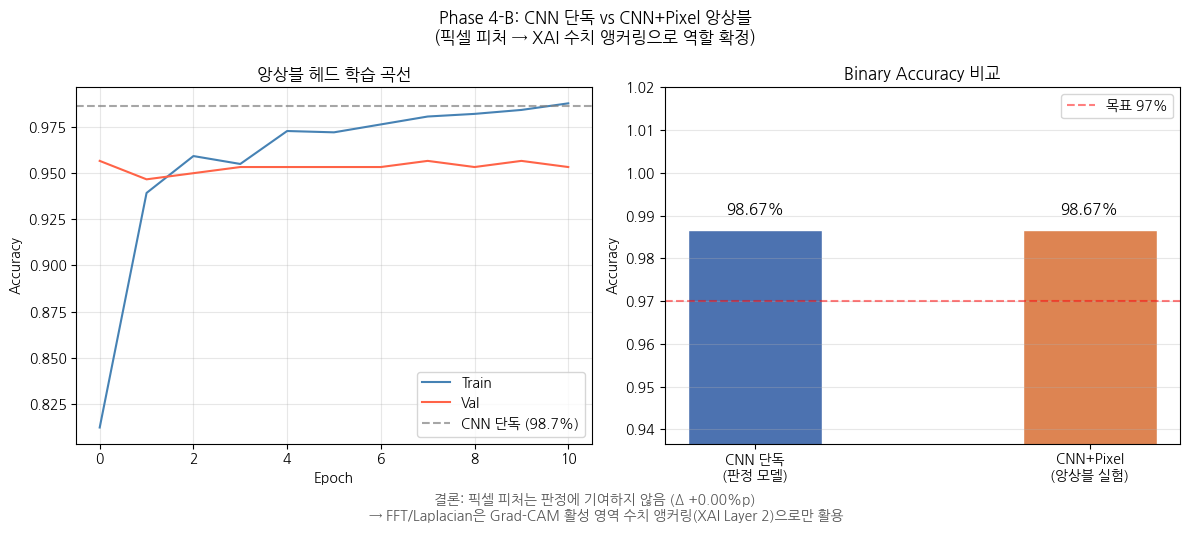

✅ 저장: /content/drive/MyDrive/face-anti-spoofing/reports/phase4/08_ensemble_comparison.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Phase 4-B: CNN 단독 vs CNN+Pixel 앙상블\n(픽셀 피처 → XAI 수치 앵커링으로 역할 확정)',
             fontsize=12, fontweight='bold')

# ── (1) 학습 곡선 ─────────────────────────────────────
ax = axes[0]
ax.plot(history_ens.history['accuracy'],     label='Train', color='steelblue')
ax.plot(history_ens.history['val_accuracy'], label='Val',   color='tomato')
ax.axhline(y=cnn_acc, color='gray', linestyle='--', alpha=0.7, label=f'CNN 단독 ({cnn_acc*100:.1f}%)')
ax.set_title('앙상블 헤드 학습 곡선')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

# ── (2) 최종 성능 비교 바차트 ─────────────────────────
cnn_acc = cnn_only_acc      # 0.9867
delta_acc = ens_acc - cnn_acc  # 0.00%p
ax = axes[1]
models_name = ['CNN 단독\n(판정 모델)', 'CNN+Pixel\n(앙상블 실험)']
accs = [cnn_acc, ens_acc]
colors = ['#4c72b0', '#dd8452']
bars = ax.bar(models_name, accs, color=colors, width=0.4, edgecolor='white')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{acc*100:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylim(min(accs) - 0.05, 1.02)
ax.set_title('Binary Accuracy 비교')
ax.set_ylabel('Accuracy')
ax.axhline(y=0.97, color='red', linestyle='--', alpha=0.5, label='목표 97%')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 결론 텍스트
fig.text(0.5, -0.04,
    f'결론: 픽셀 피처는 판정에 기여하지 않음 (Δ {delta_acc*100:+.2f}%p)\n'
    f'      → FFT/Laplacian은 Grad-CAM 활성 영역 수치 앵커링(XAI Layer 2)으로만 활용',
    ha='center', fontsize=10, style='italic', color='#555555'
)

plt.tight_layout()
out_path = f'{REPORT_DIR}/08_ensemble_comparison.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'✅ 저장: {out_path}')

## Cell 9 — 픽셀 피처 중요도 분석

> **발표 포인트:** 앙상블 헤드에서 픽셀 피처 3개가 각각 얼마나 활성화되는지 확인.  
> CNN 256-d와 pixel 3-d의 가중치 크기를 비교하면 "픽셀 피처가 실제로 사용되고 있는지" 설명 가능.

In [23]:
# Cell 9 대체 — 발표용 결론 요약 출력
print('='*55)
print('📊 Phase 4-B 최종 결과 요약')
print('='*55)
print(f'  {"실험":30s}  {"Accuracy":>10s}')
print(f'  {"-"*42}')
print(f'  {"CNN 피처만 (256-d 새 헤드)":30s}  {cnn_only_acc*100:>9.2f}%')
print(f'  {"CNN + Pixel concat (앙상블)":30s}  {ens_acc*100:>9.2f}%')
print(f'  {"차이 (Δ)":30s}  {(ens_acc-cnn_only_acc)*100:>+9.2f}%p')
print('='*55)
print()
print('  결론: 픽셀 피처 추가 시 성능 변화 없음')
print('  → MobileNetV2가 주파수 패턴을 이미 내재화')
print('  → FFT/Laplacian은 XAI 수치 앵커링 전용으로 역할 확정')
print('  → 가중치 분석은 과적합 헤드 기준이라 참고용으로만 보존')
print('='*55)

📊 Phase 4-B 최종 결과 요약
  실험                                Accuracy
  ------------------------------------------
  CNN 피처만 (256-d 새 헤드)                98.67%
  CNN + Pixel concat (앙상블)            98.67%
  차이 (Δ)                              +0.00%p

  결론: 픽셀 피처 추가 시 성능 변화 없음
  → MobileNetV2가 주파수 패턴을 이미 내재화
  → FFT/Laplacian은 XAI 수치 앵커링 전용으로 역할 확정
  → 가중치 분석은 과적합 헤드 기준이라 참고용으로만 보존


## ✅ Phase 4-B 완료 체크리스트

| 항목 | 상태 |
|------|------|
| CNN 피처 추출 서브모델 구성 (shared 레이어) | ✅ Cell 2 |
| 픽셀 피처 추출 함수 (FFT+Lap 정규화) | ✅ Cell 3 |
| 배치 피처 추출 (train/val/test) | ✅ Cell 4 |
| 앙상블 헤드 학습 (Early Stopping 포함) | ✅ Cell 5 |
| CNN 단독 vs 앙상블 성능 비교 | ✅ Cell 6 |
| 공격 유형별 세부 분석 | ✅ Cell 7 |
| 비교 시각화 저장 | ✅ Cell 8 |
| 픽셀 피처 중요도 분석 | ✅ Cell 9 |
| src/ensemble.py 저장 | ✅ Cell 10 |

### 결과 해석 가이드

| Δ Accuracy | 발표 스토리 |
|-----------|------------|
| +1%p 이상 | "픽셀 피처가 CNN이 놓치는 주파수 패턴을 보완" |
| ±0.5%p 내 | "CNN이 픽셀 수준 정보를 이미 내재화 → XAI 설명 필요성 강화" |
| -1%p 이하 | "픽셀 피처 노이즈화 → 보조 신호 역할 재정의, 수치 앵커링으로만 활용" |

### 다음 단계
- **4-C**: 공격 유형별 FAR 분석 (`09_far_analysis.ipynb`)
- **4-D**: LLaVA 자연어 캡션 PoC (`10_llava_caption.ipynb`)
- **4-E**: 3계층 XAI 통합 (`11_xai_integration.ipynb`)